# Analyse Exploratoire des Données

Étapes :
1. Chargement et aperçu général
2. Distribution des classes 
3. Analyse des longueurs de texte
4. Qualité des données (valeurs manquantes, doublons)
5. Analyse textuelle (mots fréquents par classe)
6. Conclusions et décisions 

In [ ]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter

from claims_classifier.config import config
from claims_classifier.data.loader import load_raw
from claims_classifier.data.cleaning import run_cleaning, LABEL_MAPPING

# Style global des graphiques
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = "sans-serif"
sns.set_theme(style="whitegrid", palette="muted")

print("Imports OK")
print(f"Dataset : {config.data.raw_csv_path}")

Matplotlib is building the font cache; this may take a moment.


✅ Imports OK
Dataset : C:\Users\chris\Desktop\claims-classifier\data\raw\complaints.csv


In [ ]:
# Chargement des données brutes
df_raw = load_raw()
print(f"Données brutes: {df_raw.shape}")
df_raw.head(3)

Shape brut : (300000, 2)


,label,text
0,Credit reporting or other personal consumer re...,"Despite multiple written requests, the unverif..."
1,Checking or savings account,My checking account has been open with Bank of...
2,Vehicle loan or lease,"Hello, My name is XXXX XXXX I am in a 72 month..."


## 1. Aperçu général

In [ ]:
print(f"Observations totales : {len(df_raw):,}")
print(f"Colonnes             : {list(df_raw.columns)}")
print(f"Classes brutes       : {df_raw['label'].nunique()}")
print(f"\nValeurs manquantes :")
print(df_raw.isnull().sum())
print(f"\nDoublons: {df_raw.duplicated(subset='text').sum():,}")

Observations totales : 300,000
Colonnes             : ['label', 'text']
Classes brutes       : 21

Valeurs manquantes :
label    0
text     0
dtype: int64

Doublons (texte identique) : 40,451


## 2. Distribution des classes brutes

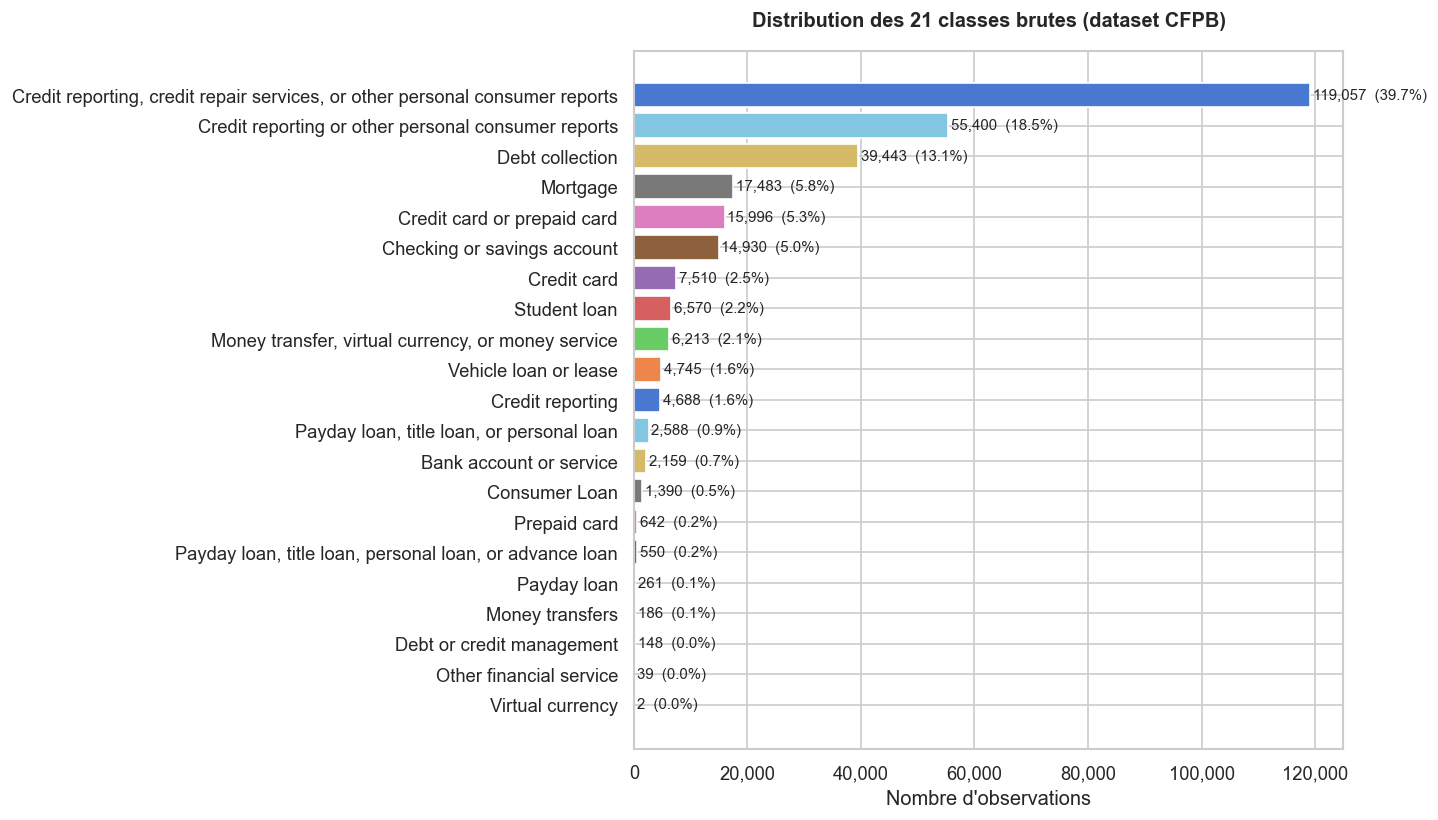

Figure sauvegardée : reports/figures/01_distribution_brute.png


In [ ]:
counts_raw = df_raw["label"].value_counts()
total = len(df_raw)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(counts_raw.index[::-1], counts_raw.values[::-1], color=sns.color_palette("muted", len(counts_raw)))

# Annotations
for bar, val in zip(bars, counts_raw.values[::-1]):
    pct = val / total * 100
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f"{val:,}  ({pct:.1f}%)", va="center", fontsize=9)

ax.set_xlabel("Nombre d'observations")
ax.set_title("Distribution des 21 classes brutes", fontweight="bold", pad=15)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig("../reports/figures/01_distribution_brute.png", bbox_inches="tight")
plt.show()
print("Figure sauvegardée : reports/figures/01_distribution_brute.png")

## 3. Fusion des classes et distribution finale

**Décision documentée** : 21 classes brutes pour 12 classes finales.

- Variantes historiques de la taxonomie 
- Classes ultra-rares fusionnées en `other` 

In [ ]:
df_clean = run_cleaning(df_raw)

counts_clean = df_clean["label"].value_counts()
total_clean = len(df_clean)

# Calcul des poids pour le Weighted F1
alpha = counts_clean / total_clean

print(f"Observations après nettoyage : {total_clean:,}")
print(f"Classes finales              : {df_clean['label'].nunique()}\n")
print(f"{'Classe':<30} {'nᵢ':>8} {'αᵢ':>8}")
print("─" * 50)
for label, count in counts_clean.items():
    print(f"{label:<30} {count:>8,} {count/total_clean:>8.3f}")

144 textes supprimes (vides ou < 3 mots apres nettoyage)


Observations après nettoyage : 299,856
Classes finales              : 12

Classe                               nᵢ       αᵢ
──────────────────────────────────────────────────
credit_reporting                179,017    0.597
debt_collection                  39,434    0.132
credit_card                      24,145    0.081
mortgage                         17,482    0.058
checking_or_savings              14,929    0.050
student_loan                      6,570    0.022
money_transfer                    6,401    0.021
vehicle_loan                      4,743    0.016
payday_loan                       3,399    0.011
bank_account_or_service           2,159    0.007
consumer_loan                     1,390    0.005
other                               187    0.001


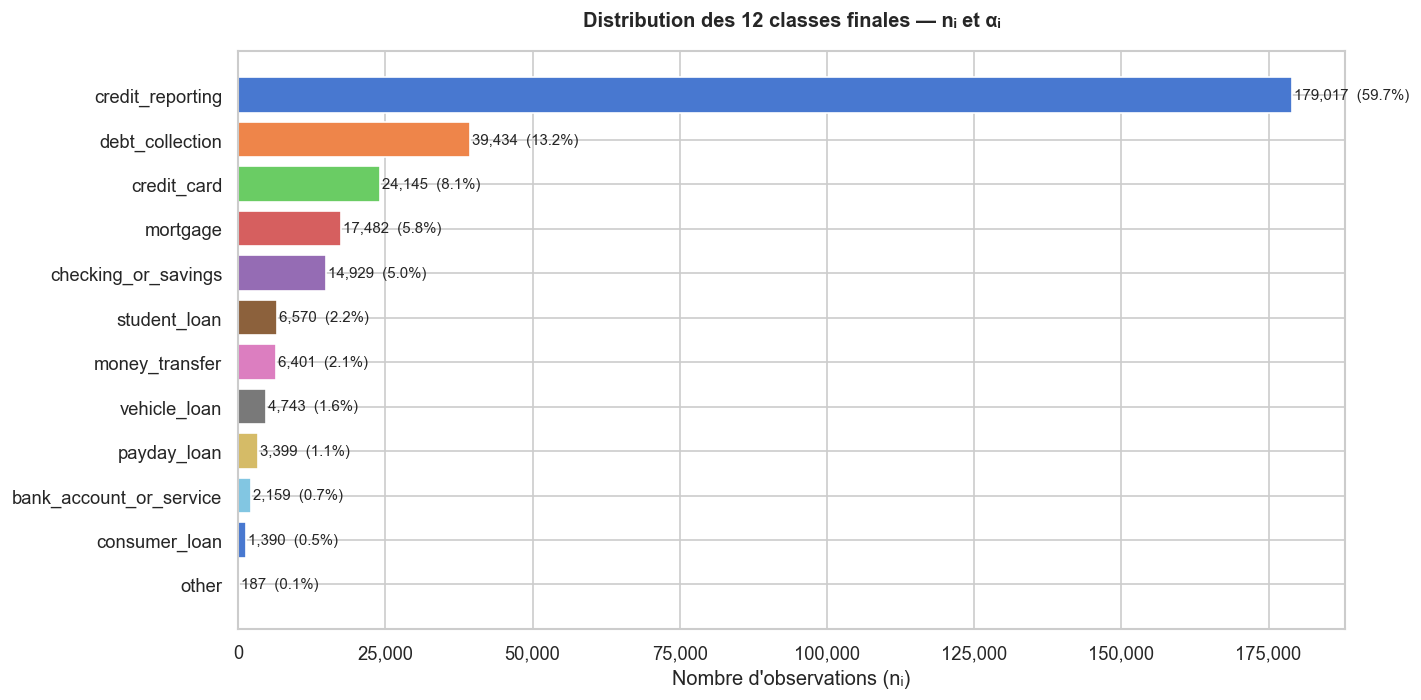

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))
colors = sns.color_palette("muted", len(counts_clean))
bars = ax.barh(counts_clean.index[::-1], counts_clean.values[::-1], color=colors[::-1])

for bar, val in zip(bars, counts_clean.values[::-1]):
    pct = val / total_clean * 100
    ax.text(bar.get_width() + 300, bar.get_y() + bar.get_height()/2,
            f"{val:,}  ({pct:.1f}%)", va="center", fontsize=9)

ax.set_xlabel("Nombre d'observations (nᵢ)")
ax.set_title("Distribution des 12 classes finales — nᵢ et αᵢ", fontweight="bold", pad=15)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig("../reports/figures/02_distribution_finale.png", bbox_inches="tight")
plt.show()

## 4. Analyse des longueurs de texte

Justification du choix `max_seq_length = 256`.

In [ ]:
df_clean["word_count"] = df_clean["text"].str.split().str.len()
df_clean["char_count"] = df_clean["text"].str.len()

print("Statistiques — nombre de mots par texte (après nettoyage) :")
stats = df_clean["word_count"].describe(percentiles=[.25, .5, .75, .90, .95, .99])
print(stats.to_string())

# Seuil retenu
threshold = config.preprocessing.max_seq_length
pct_covered = (df_clean["word_count"] <= threshold).mean() * 100
print(f"\n max_seq_length={threshold} couvre {pct_covered:.1f}% des textes")

Statistiques — nombre de mots par texte (après nettoyage) :
count    299856.000000
mean        162.375927
std         209.919893
min           3.000000
25%          54.000000
50%         103.000000
75%         190.000000
90%         344.000000
95%         494.000000
99%         981.000000
max        5252.000000

✅ max_seq_length=256 couvre 83.5% des textes


## 5. Mots les plus fréquents (Top 15 par classe)

Vérification que le nettoyage est cohérent et que chaque classe a un vocabulaire distinctif.

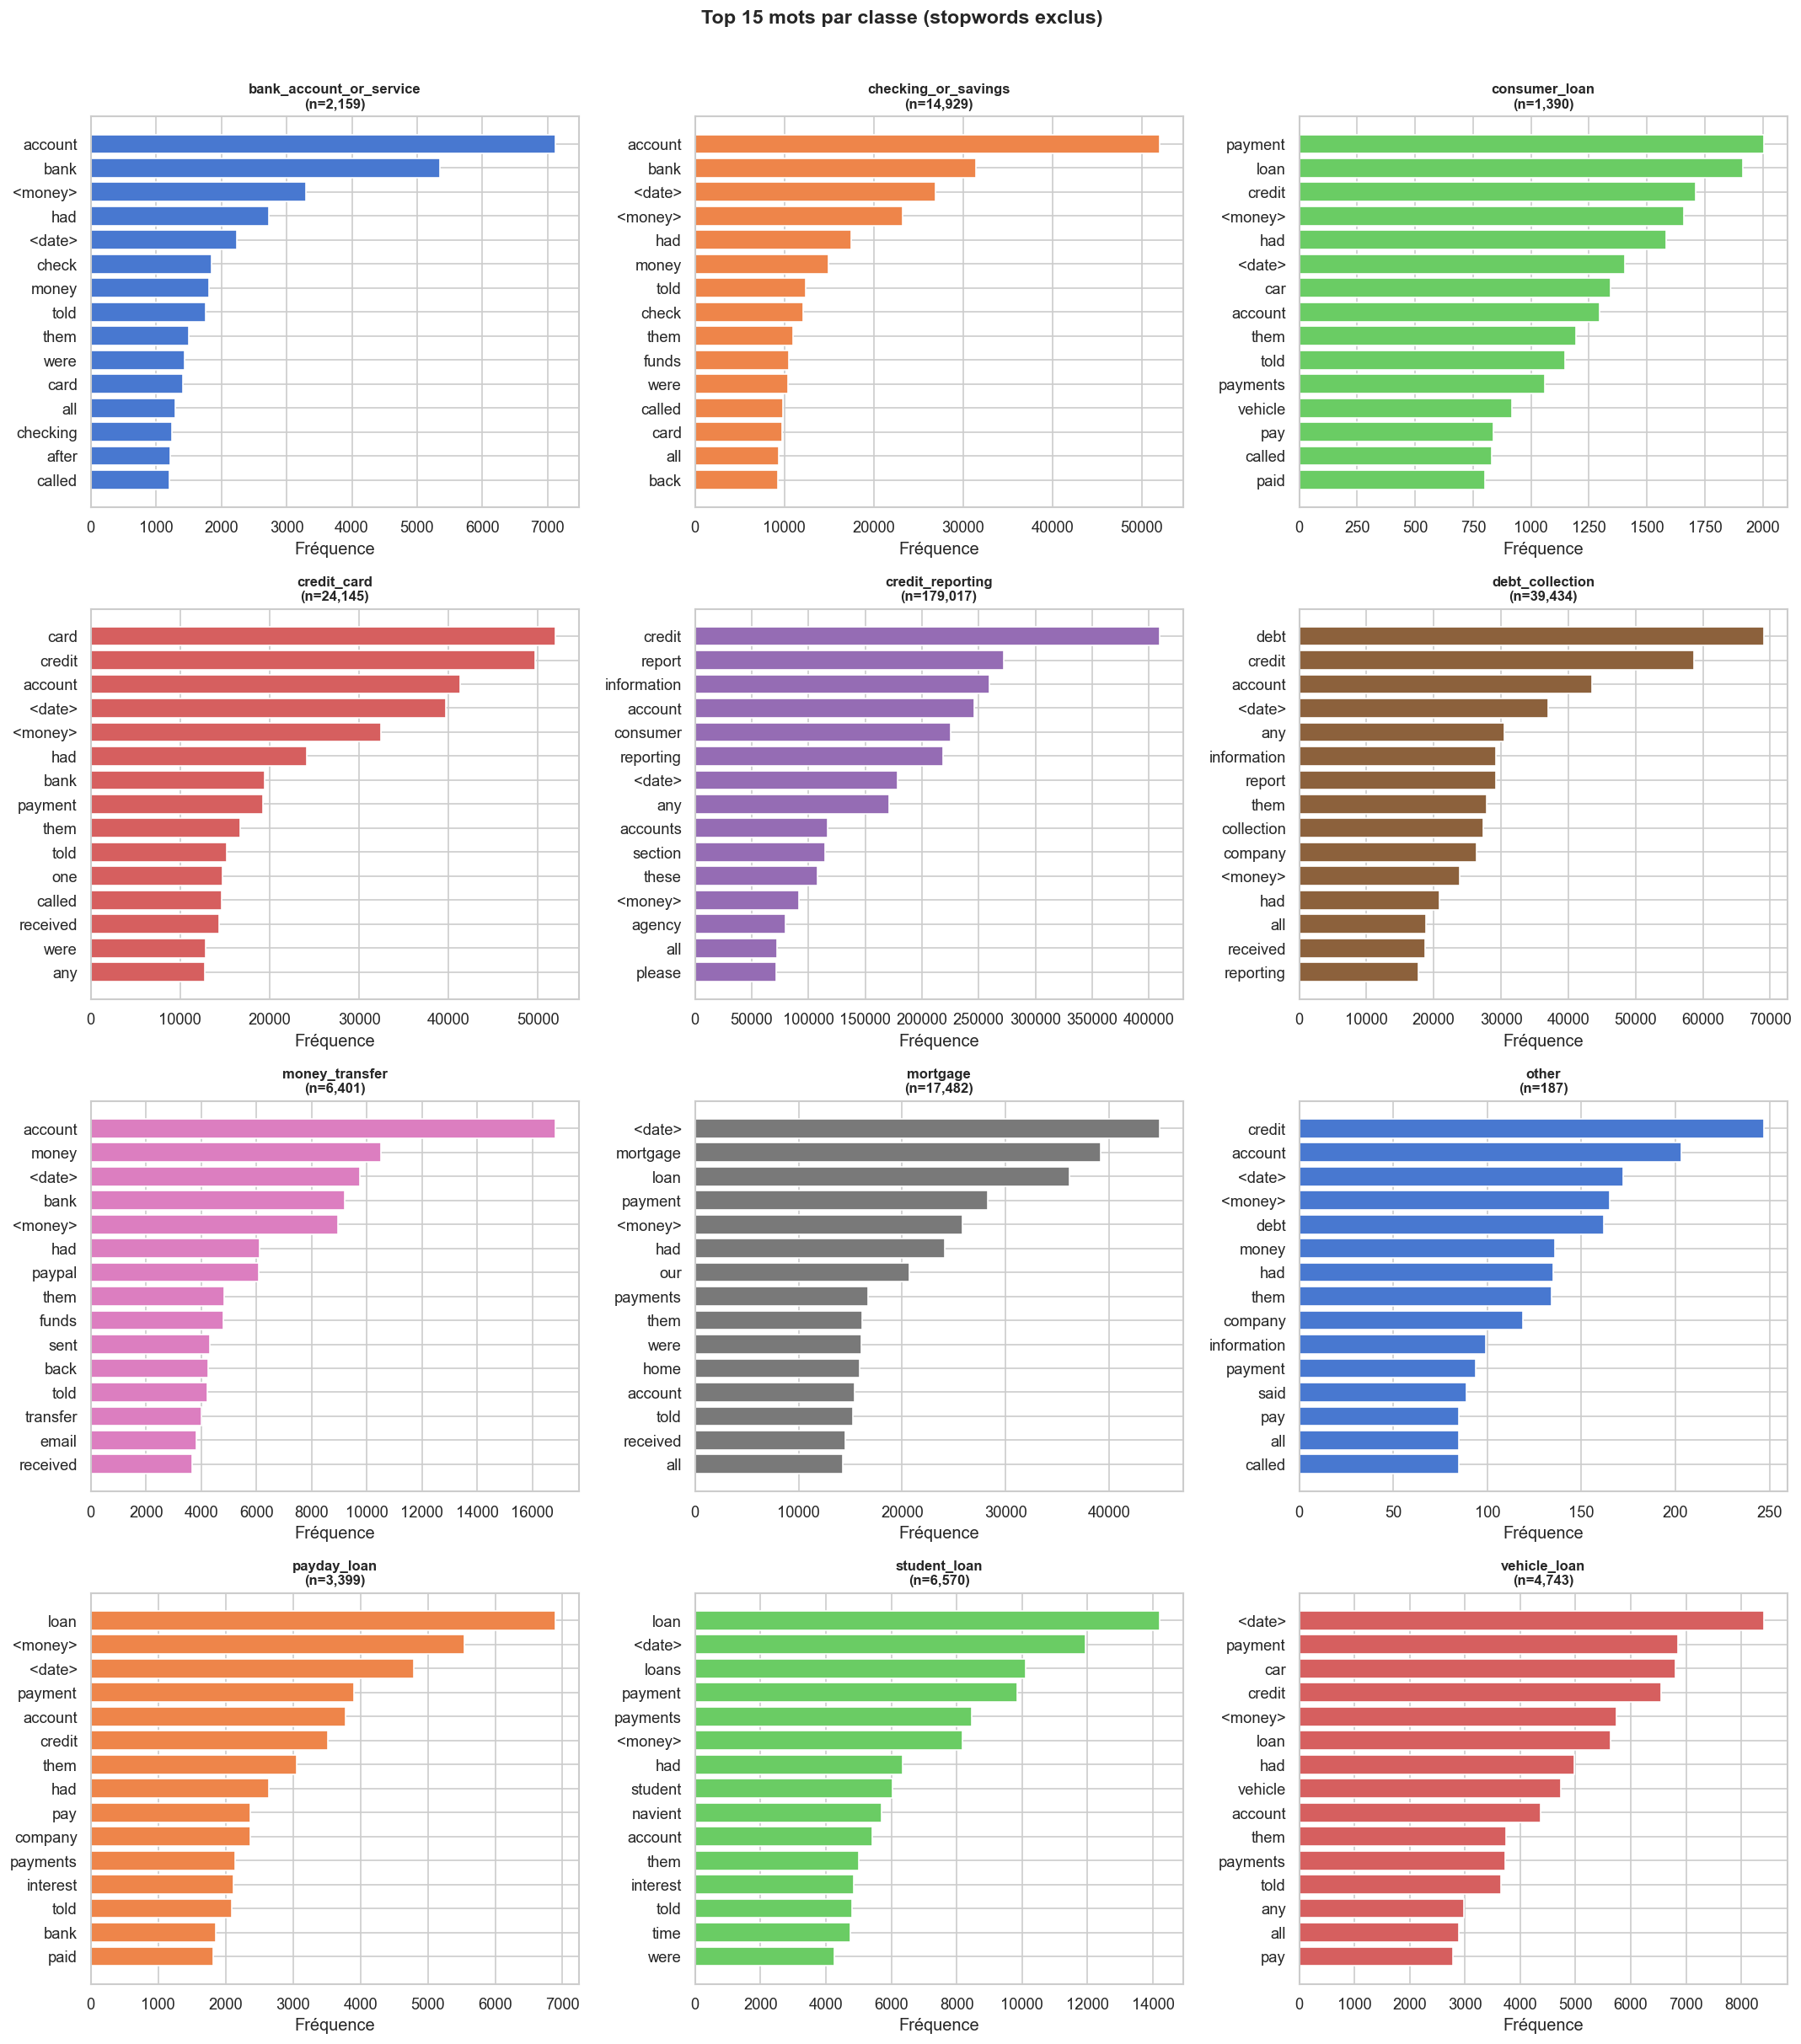

In [9]:
# Mots stop simples a exclure (trop generiques)
STOPWORDS = {
    "the", "a", "an", "and", "or", "to", "of", "in", "i", "my",
    "is", "was", "have", "has", "they", "it", "on", "for", "with",
    "that", "this", "be", "not", "at", "me", "am", "are", "been",
    "but", "as", "from", "by", "we", "you", "he", "she", "do",
    "did", "so", "if", "no", "up", "out", "about", "their", "its",
    "would", "could", "will", "can", "also", "which", "when", "there"
}

fig, axes = plt.subplots(4, 3, figsize=(18, 20))
axes = axes.flatten()

for idx, label in enumerate(sorted(df_clean["label"].unique())):
    subset = df_clean[df_clean["label"] == label]["text"]
    counter = Counter()
    for text in subset:
        words = [w for w in text.split() if w not in STOPWORDS and len(w) > 2]
        counter.update(words)

    top_words = counter.most_common(15)
    words, freqs = zip(*top_words)

    axes[idx].barh(list(words)[::-1], list(freqs)[::-1],
                   color=sns.color_palette("muted")[idx % 8])
    axes[idx].set_title(f"{label}\n(n={len(subset):,})", fontsize=10, fontweight="bold")
    axes[idx].set_xlabel("Fréquence")

plt.suptitle("Top 15 mots par classe (stopwords exclus)", fontsize=14,
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../reports/figures/04_top_mots_par_classe.png", bbox_inches="tight")
plt.show()

## 6. Déséquilibre des classes 

Le déséquilibre est **extrême** : `credit_reporting` représente ~60% du dataset.

- **Split stratifié** : chaque split conserve la même distribution
- **CrossEntropy pondérée** : poids inversement proportionnels à la fréquence (cours Régularisation)

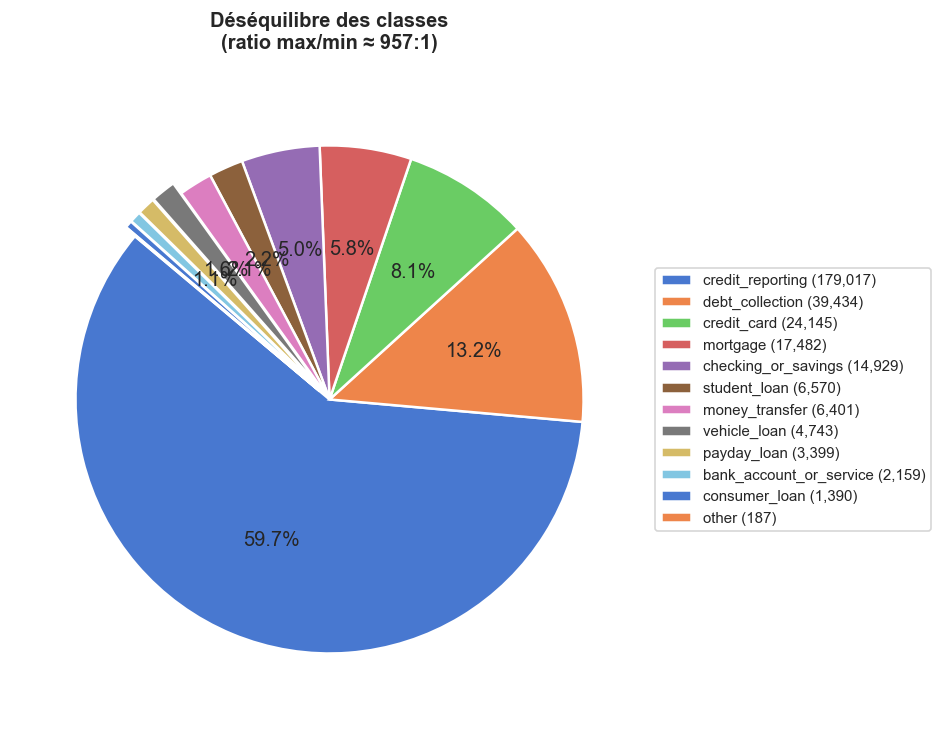

Ratio max/min : 957:1
→ CrossEntropy pondérée indispensable


In [10]:
fig, ax = plt.subplots(figsize=(8, 8))

labels_pie = counts_clean.index.tolist()
sizes = counts_clean.values.tolist()
colors = sns.color_palette("muted", len(labels_pie))

# Explode les petites classes pour les rendre visibles
explode = [0.05 if s / total_clean < 0.02 else 0 for s in sizes]

wedges, texts, autotexts = ax.pie(
    sizes, labels=None, autopct=lambda p: f"{p:.1f}%" if p > 1 else "",
    colors=colors, explode=explode, startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)

ax.legend(wedges, [f"{l} ({s:,})" for l, s in zip(labels_pie, sizes)],
          loc="center left", bbox_to_anchor=(1, 0.5), fontsize=9)
ax.set_title("Déséquilibre des classes\n(ratio max/min ≈ 957:1)",
             fontweight="bold", pad=20)

plt.tight_layout()
plt.savefig("../reports/figures/05_desequilibre_classes.png", bbox_inches="tight")
plt.show()

ratio = counts_clean.max() / counts_clean.min()
print(f"Ratio max/min : {ratio:.0f}:1")
print(f"→ CrossEntropy pondérée indispensable")

## 7. Conclusions et décisions de retraitement

### Ce qu'on a observé
| Observation | Valeur | Impact |
|---|---|---|
| Observations totales | 299,856 | Suffisant pour le DL |
| Classes finales | 12 | Après fusion de 4 groupes redondants |
| Classe dominante | `credit_reporting` 59.7% | Déséquilibre extrême |
| Ratio max/min | ~957:1 | CrossEntropy pondérée obligatoire |
| Médiane longueur | ~100 mots | `max_seq_length=256` couvre ~90% |
| Textes anonymisés | XXXX, dates, montants | Remplacés par tokens spéciaux |

### Décisions prises
1. **Fusion 21 → 12 classes** : variantes taxonomiques regroupées, ultra-rares → `other`
2. **`max_seq_length = 256`** : couvre ~90% des textes, bon compromis vitesse/qualité
3. **`vocab_size = 20,000`** : top mots sur corpus train uniquement (anti-fuite)
4. **Tokens spéciaux** : `<date>` et `<money>` conservent l'info anonymisée
5. **Split stratifié 70/15/15** : distribution préservée dans chaque split
6. **CrossEntropy pondérée** : compense le déséquilibre lors de l'entraînement

### Prochaine étape
→ Construction et entraînement du modèle (MLP puis TextCNN)